In [71]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from omegaconf import DictConfig
import lightning as L
from lightning.pytorch.loggers import TensorBoardLogger
from torch.optim.lr_scheduler import LinearLR, CosineAnnealingLR, SequentialLR


from timeseries.augementation.v1 import TimeSeriesTransform
from timeseries.preprocessing.scalers import TorchStandardScaler
from timeseries.data.pems import PeMS08,PeMS08AugmentedDataset
from timeseries.visualizations.datamodule import visualize_pems_tuple
from timeseries.model.tcn import TimeSeriesEncoder
from timeseries.model.rnn import TimeSeriesLSTMEncoder, TimeSeriesGRUEncoder, TimeSeriesAttentionRNNEncoder



In [72]:
class PeMS08DataModule(L.LightningDataModule):
    def __init__(self, cfg: DictConfig):
        super().__init__()
        self.cfg = cfg
        self.save_hyperparameters()

        # --- 1. Transformations-Definitionen ---
        # Analogon zur 'self.aug' in ImageNetDataModule
        self.aug_transform = TimeSeriesTransform(
            output_length=self.cfg.window_size, 
            scale_range=(1, 1), 
            jitter_std=0.0, 
            p_noise=0.1, 
            p_freq_mask=0.0,
            max_freq_ratio=0.0,
            p_temporal_mask=0.9,
            p_transform=0.6 # Keine Augmentationen
        )
        
        # Analogon zur 'self.test_transform' in ImageNetDataModule
        # Die Test-Transformation sollte nur Normalisierungen/Resizing ohne starke Augmentation durchführen.
      
        self.test_transform = TimeSeriesTransform(
            output_length=self.cfg.window_size, 
            scale_range=(1.0, 1.0), # Keine Skalierung
            jitter_std=0.0, 
            p_noise=0.0, 
            p_freq_mask=0.0,
            max_freq_ratio=0.0,
            p_temporal_mask=0.0,
            p_transform=0.0 # Keine Augmentationen
        )

        self.pems08 = None
        self.train_ds = None
        self.val_ds = None
        self.scaler = TorchStandardScaler()
    def prepare_data(self):
        pems08 = PeMS08(root="./data/pems08", mask_zeros=True)

        train = torch.tensor(pems08.target.iloc[:int(len(pems08.target)*0.8)].values, dtype=torch.float32)
        test  = torch.tensor(pems08.target.iloc[int(len(pems08.target)*0.8):].values, dtype=torch.float32)
        self.train_scaled = self.scaler.fit_transform(train)
        self.test_scaled = self.scaler.transform(test)
        

    def setup(self, stage = None):
        self.train_ds = PeMS08AugmentedDataset(
            self.train_scaled, 
            transform=self.aug_transform, 
            V=self.cfg.V, 
            window_size=self.cfg.window_size,
            target_window_size=self.cfg.target_window_size, 
            stride=self.cfg.stride,
            t1_window=True,
            sensors=self.cfg.sensors if hasattr(self.cfg,'sensors') else None
        )
        
    
        self.val_ds = PeMS08AugmentedDataset(
            self.test_scaled, # Val-Daten müssten hier verwendet werden
            transform=self.test_transform, 
            V=1, 
            window_size=self.cfg.window_size,
            target_window_size=self.cfg.target_window_size,  
            stride=self.cfg.stride,
            t1_window=False,
            sensors=self.cfg.sensors if hasattr(self.cfg,'sensors') else None
        )

    def train_dataloader(self):
        return DataLoader(
            self.train_ds,
            batch_size=self.cfg.bs,
            shuffle=True,
            drop_last=True,
            num_workers=self.cfg.num_workers,
            pin_memory=True,
        )

    def val_dataloader(self):
        return DataLoader(
            self.val_ds,
            # Val batch size kann größer sein
            batch_size=self.cfg.bs_val if hasattr(self.cfg,'bs_val') else len(self.val_ds)//2, 
            num_workers=self.cfg.num_workers,
            drop_last=True,
            pin_memory=True,
        )

In [73]:
class SIGReg(torch.nn.Module):
    def __init__(self, knots=17):
        super().__init__()
        t = torch.linspace(0, 3, knots, dtype=torch.float32)
        dt = 3 / (knots - 1)
        weights = torch.full((knots,), 2 * dt, dtype=torch.float32)
        weights[[0, -1]] = dt
        window = torch.exp(-t.square() / 2.0)
        self.register_buffer("t", t)
        self.register_buffer("phi", window)
        self.register_buffer("weights", weights * window)

    def forward(self, proj):
        A = torch.randn(proj.size(-1), 256, device="cuda")
        A = A.div_(A.norm(p=2, dim=0))
        x_t = (proj @ A).unsqueeze(-1) * self.t
        err = (x_t.cos().mean(-3) - self.phi).square() + x_t.sin().mean(-3).square()
        statistic = (err @ self.weights) 
        return statistic.mean()

In [74]:
from omegaconf import DictConfig
cfg=DictConfig({
    'window_size': 64,
    'target_window_size':12,
    'sensors': list(range(170)),  # Alle Sensoren verwenden
    'V': 20,          # Anzahl der Views (V)
    'bs': 32,        # Batch Size Training
    'stride': 3,    # Überlappung
    'num_workers': 25,
    'encoder_dim':24,
    'proj_dim':32,
    'epochs':1000,
    'accum_steps':1,
    'lr':5e-3,'lamb':0.03,'probe_lambda':0.1,
})

In [75]:
datamodule = PeMS08DataModule(cfg)
datamodule.prepare_data()
datamodule.setup()

/home/crispy/lejepa/src/timeseries/data/pems.py:109: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  index = pd.date_range(start=self.start_date, periods=len(data), freq='5T')


In [76]:
len(datamodule.val_ds)

1166

/home/crispy/lejepa/src/timeseries/data/pems.py:109: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  index = pd.date_range(start=self.start_date, periods=len(data), freq='5T')


--- Visualisierung (train-Daten) ---
Fensterlängen: T0/T1=64, Target=12. | Views pro Fenster (V): 20. | T1 enthalten: True.
Tatsächliche Anzahl Views im Batch: 20
WARNUNG: T1-Fenster erwartet, aber keine T1-Views im Batch gefunden.


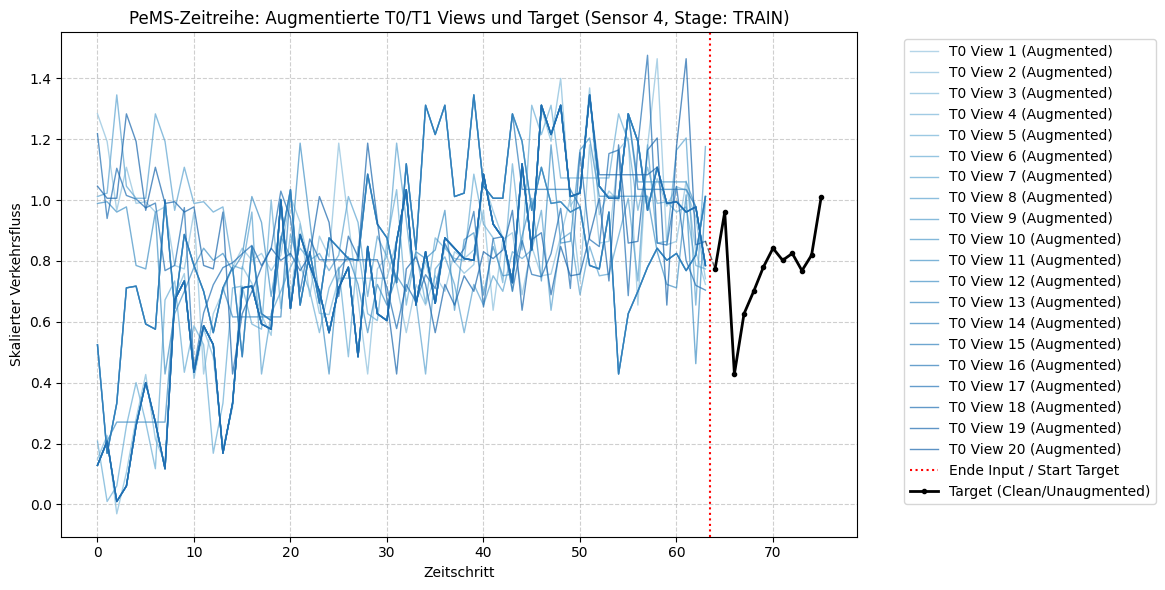

In [77]:
visualize_pems_tuple(datamodule, batch_index=5, sensor_index=4, stage='train')

In [78]:
class ForecastProbe(nn.Module):
    """
    Diese Probe nimmt die Enkoder-Einbettung [D_emb] und projiziert sie auf 
    die Form des Ziel-Fensters [C, L].
    
    Wir verwenden eine einfache MLP-Dekoder-Struktur.
    """
    def __init__(self, input_dim: int, output_channels: int, output_length: int):
        super().__init__()
        self.output_channels = output_channels
        self.output_length = output_length
        
        # Sequentieller Decoder: nimmt [D_emb] -> vergrößert -> projiziert auf [C*L]
        self.net = nn.Sequential(
            nn.LayerNorm(input_dim),
            nn.Linear(input_dim, output_channels * output_length)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        y_pred_flat = self.net(x)
        return y_pred_flat.reshape(x.size(0), self.output_channels, self.output_length)

In [79]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

class ForecastProbe(nn.Module):
    """
    Improves upon the flat Linear Probe by factorizing the decoding process.
    1. Channel Projector: Maps global embedding to Channel-specific embeddings.
    2. Temporal Decoder: Decodes the time horizon for each channel.
    """
    def __init__(self, input_dim: int, output_channels: int, output_length: int, decode_dim: int = 64):
        super().__init__()
        self.output_channels = output_channels
        self.output_length = output_length
        self.decode_dim = decode_dim

        # 1. Expand to Channel-Space: [B, Emb] -> [B, C * Decode_Dim]
        # This allows the model to learn specific features for each channel.
        self.channel_proj = nn.Sequential(
            nn.Linear(input_dim, output_channels * decode_dim),
            nn.LayerNorm(output_channels * decode_dim),
            nn.GELU()
        )

        # 2. Decode Time: [B, C, Decode_Dim] -> [B, C, Output_Length]
        # Using a shared Linear layer forces the model to learn a generalized 
        # temporal dynamic, reducing overfitting compared to a dense matrix.
        self.temporal_decoder = nn.Linear(decode_dim, output_length)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B = x.size(0)
        
        # Step 1: Project to Channel Latents
        x_channels = self.channel_proj(x) # [B, C * Decode_Dim]
        
        # Step 2: Reshape to separate channels
        x_channels = x_channels.reshape(B, self.output_channels, self.decode_dim)
        
        # Step 3: Decode time horizon
        # The Linear layer applies to the last dimension (decode_dim)
        y_pred = self.temporal_decoder(x_channels) # [B, C, L]
        
        return y_pred

class TimeSeriesLeJEPA(L.LightningModule):
    def __init__(self, cfg: DictConfig):
        super().__init__()
        self.cfg = cfg
        self.save_hyperparameters(cfg) 

        # --- Modul-Anpassungen ---
        # 1. Backbone: Verwenden Sie den TimeSeriesConvEncoder
        self.net = TimeSeriesLSTMEncoder(
            input_channels=len(cfg.sensors), 
            encoder_output_dim=cfg.encoder_dim, 
            proj_dim=cfg.proj_dim, 
        )
        
        # 2. Probe: Verwenden Sie den Forecasting Probe Head
        # Er nimmt die Enkoder-Einbettung (emb) und sagt das nächste Fenster voraus.
        self.probe = ForecastProbe(
            input_dim=cfg.encoder_dim, 
            output_channels=len(cfg.sensors), 
            output_length=cfg.target_window_size
        )
        self.sigreg = SIGReg(knots=17)# sigreg loss works the other ones not
        self.scaler=datamodule.scaler

        self.lr=cfg.lr
        #self.init_lamb=cfg.lamb/20
        self.lamb=0.5#cfg.lamb#/20
    def on_fit_start(self):
        if self.scaler is not None:
            self.scaler.to(self.device)
        
    def forward(self, x):
        # x shape: [B, V, C, L]
        return self.net(x)

    # ----------------------------------------------------------
    # KEINE ÄNDERUNGEN HIER, die Optimizierer-Logik bleibt gleich,
    # muss nur mit den richtigen cfg-Werten konfiguriert werden.
    # -----------------------------------------------------------
    def configure_optimizers(self):
         # ... [Unveränderte Logik für AdamW und Scheduler] ...
        g1 = {"params": self.net.parameters(), "lr": self.lr,}# "weight_decay": 5e-4}
        g2 = {"params": self.probe.parameters(), "lr": 2e-4, }#"weight_decay": 1e-5}
        opt = torch.optim.AdamW([g2, g1])
        
        # Notwendige Anpassungen für die Datamodule-Zugriff (falls im Test nicht verfügbar, verwenden Sie einen Fallback)
        if self.trainer is None or self.trainer.datamodule is None or self.trainer.datamodule.train_dataloader() is None:
            train_steps_per_epoch = 100 # Fallback
        else:
            train_batches = len(self.trainer.datamodule.train_dataloader())
            train_steps_per_epoch = (train_batches + self.cfg.accum_steps - 1) // self.cfg.accum_steps

        warmup_steps = train_steps_per_epoch*50
        total_steps = train_steps_per_epoch * self.cfg.epochs
        
        #s1 = LinearLR(opt, start_factor=0.01, total_iters=warmup_steps)
        #t_max = max(1, total_steps - warmup_steps)
        #s2 = CosineAnnealingLR(opt, T_max=total_steps, eta_min=1e-5)# use plateau lr rade? or restarts?
        #scheduler = SequentialLR(opt, schedulers=[s1, s2], milestones=[warmup_steps])
        scheduler = ReduceLROnPlateau(
            opt,
            mode="min",
            factor=0.7,
            patience=50,
            min_lr=1e-5,
        )

        return {
            "optimizer": opt,
            "lr_scheduler": {
                "scheduler": scheduler,
                "interval": "epoch",   # ReduceLROnPlateau must run per epoch
                "monitor": "train/lejepa", # or your chosen metric
                "frequency": 1,
            },
        }

    # -----------------------------------------------------------
    # def on_train_epoch_start(self):
    #     if self.current_epoch<20:
    #         self.lamb+=self.init_lamb
    def training_step(self, batch, batch_idx):
        # vs (Views): [B, V, C, L], target: [B, C, L]
        vs, target = batch
        
        # emb: [V, B, D_emb], proj: [V, B, D_proj]
        emb, proj = self(vs)
        # print(f"Embedding: {emb.shape}")
        # print(f"proj: {proj.shape}")
        # print(f"target: {target.shape}")
        # 1. LeJEPA Loss Berechnung
        # proj.shape ist [V, B, D_proj]
        inv_loss = (proj.mean(0) - proj).square().mean() # macht verschiedene Ansichten ähnlich
        #maybe use a similar loss to make t1 ansichten similar to t0 ansichten?
        sigreg_loss = self.sigreg(proj) # regularisiert die Repräsentationen
        if sigreg_loss>2*inv_loss:
            self.lamb=1.5
        else:
            self.lamb=0.02
        lejepa_loss = sigreg_loss * self.lamb + inv_loss * (1 - self.lamb)
        
        
        y_rep, yhat = target.repeat_interleave(self.cfg.V), self.probe(emb.detach())
        # print(f"y_rep shape: {y_rep.shape}, yhat shape: {yhat.shape}")
        y_rep = y_rep.view_as(yhat)
        # Mean Squared Error (MSE) als Regressionsverlust
        probe_loss = F.huber_loss(yhat, y_rep)
        
        # Gesamter Verlust
        loss = lejepa_loss + probe_loss * self.cfg.probe_lambda 

        # Logging
        opt = self.optimizers()

        lr_probe = opt.param_groups[0]["lr"]
        lr_main = opt.param_groups[1]["lr"]
        self.log_dict(
            {

                "train/forecasting_mse": probe_loss,
                "lr/main":lr_main,
                "lr/probe": lr_probe
    
        
            },
            on_step=False,
            on_epoch=True,
            prog_bar=False,
            sync_dist=True,
        )
        self.log_dict(
            {
                
                "train/lejepa": lejepa_loss,
                "train/sigreg": sigreg_loss,
                "train/inv": inv_loss,
                "train/loss": loss,
    
            },
            on_step=True,
            on_epoch=True,
            prog_bar=True,
            sync_dist=True,
        )
        
        return loss

    def validation_step(self, batch, batch_idx):
        vs, target = batch  # vs: [B, V, C, L], target: [B, C, L]

        # --- Forward (nur 1 View wird benutzt) ---
        emb, _ = self(vs)                  # emb: [V, B, D]
        yhat = self.probe(emb)             # yhat: [B, C, L]

        # --- Validation Loss im normalisierten Raum ---
        val_loss = F.huber_loss(yhat, target)

        # --- Inverse scaling (TorchStandardScaler arbeitet mit Torch-Tensors) ---
        yhat_inv = self.scaler.inverse_transform(yhat)
        target_inv = self.scaler.inverse_transform(target)

        # --- MAE im Originalraum ---
        val_mae = F.l1_loss(yhat_inv, target_inv)

        self.log_dict(
            {
                "val/forecasting_mse": val_loss,
                "val/forecasting_mae": val_mae,
            },
            on_step=False,
            on_epoch=True,
            sync_dist=True,
        )

In [80]:
import torch
import lightning as L
import matplotlib.pyplot as plt
import numpy as np
import umap
import seaborn as sns
from torch.utils.data import DataLoader

class VisualizationCallback(L.Callback):
    def __init__(self, num_samples_plot=3, umap_every_n_epochs=5, num_umap_batches=10):
        """
        Args:
            num_samples_plot: Wie viele Beispiele (Zeitreihen) geplottet werden sollen.
            umap_every_n_epochs: UMAP ist teuer, daher nur alle N Epochen ausführen.
            num_umap_batches: Wie viele Batches für UMAP gesammelt werden (mehr = genaueres Bild, aber langsamer).
        """
        super().__init__()
        self.num_samples_plot = num_samples_plot
        self.umap_every_n_epochs = umap_every_n_epochs
        self.num_umap_batches = num_umap_batches

    def on_validation_epoch_end(self, trainer, pl_module):
        # 1. Daten holen (wir nehmen einen Teil des Val-Sets)
        # Wir müssen sicherstellen, dass wir nicht den Iterator des Trainers durcheinander bringen,
        # daher holen wir den Dataloader neu.
        val_loader = trainer.datamodule.val_dataloader()
        
        # Container für UMAP
        all_embeddings = []
        all_times = [] # Zeitindex für Färbung
        
        # Container für Prediction Plots (nur vom ersten Batch)
        plot_data = None
        
        device = pl_module.device
        pl_module.eval() # Sicherstellen, dass wir im Eval-Mode sind

        with torch.no_grad():
            for i, batch in enumerate(val_loader):
                if i >= self.num_umap_batches:
                    break
                
                # Batch entpacken (Annahme: batch = (vs, target))
                vs, target = batch
                vs = vs.to(device)
                target = target.to(device)
                
                # Forward Pass
                # Wir nutzen nur die erste View für die Inferenz im Val-Mode
                emb, _ = pl_module(vs) # emb: [V, B, D] -> wir brauchen [B, D]
                
                # Achtung: Ihr Model Output für emb ist [V, B, D] oder [N*V, D] je nach Implementierung.
                # Im Validation Step Ihres Codes: emb shape [V, B, D].
                # Wir nehmen den Mean über die Views oder nur die erste View für UMAP.
                # Hier nehmen wir View 0.
                if emb.ndim == 3: 
                    emb_flat = emb[0] # [B, D]
                else:
                    # Falls forward [N*V, D] zurückgibt (wie im TimeSeriesAttentionRNNEncoder code)
                    # müssen wir es auflösen.
                    # Annahme basierend auf Ihrem Code: forward gibt [N*V, ...] zurück
                    # Aber im Val-Step nutzen Sie V=1.
                    emb_flat = emb 

                yhat = pl_module.probe(emb_flat)
                
                # Daten für UMAP sammeln
                all_embeddings.append(emb_flat.cpu().numpy())
                # Zeit-Index simulieren (Batch Index * Batch Size + Offset)
                batch_size = vs.shape[0]
                time_indices = np.arange(i * batch_size, (i + 1) * batch_size)
                all_times.append(time_indices)
                
                # Daten für Plotting speichern (nur vom ersten Batch)
                if i == 0:
                    # Inverse Transform für realistische Plots
                    # vs shape: [B, V, C, L] -> wir nehmen View 0 -> [B, C, L]
                    input_seq = vs[:, 0, :, :] 
                    
                    # Scaling rückgängig machen
                    if hasattr(pl_module, 'scaler') and pl_module.scaler is not None:
                        input_inv = pl_module.scaler.inverse_transform(input_seq)
                        target_inv = pl_module.scaler.inverse_transform(target)
                        yhat_inv = pl_module.scaler.inverse_transform(yhat)
                    else:
                        input_inv = input_seq
                        target_inv = target
                        yhat_inv = yhat
                        
                    plot_data = {
                        'input': input_inv.cpu(),
                        'target': target_inv.cpu(),
                        'prediction': yhat_inv.cpu()
                    }

        # --- A. Plot Predictions ---
        self._plot_predictions(trainer, plot_data)

        # --- B. Plot UMAP (nur alle N Epochen) ---
        if (trainer.current_epoch + 1) % self.umap_every_n_epochs == 0:
            embeddings_concat = np.concatenate(all_embeddings, axis=0)
            times_concat = np.concatenate(all_times, axis=0)
            self._plot_umap(trainer, embeddings_concat, times_concat)

    def _plot_predictions(self, trainer, data):
        """ Erstellt Matplotlib Plots für Zeitreihen """
        inputs = data['input']      # [B, C, L_in]
        targets = data['target']    # [B, C, L_out]
        preds = data['prediction']  # [B, C, L_out]
        
        num_samples = min(self.num_samples_plot, inputs.shape[0])
        
        # Zufälligen Sensor auswählen, um nicht immer Sensor 0 zu plotten
        C = inputs.shape[1]
        sensor_idx = np.random.randint(0, C)
        
        fig, axes = plt.subplots(num_samples, 1, figsize=(10, 4 * num_samples), sharex=False)
        if num_samples == 1: axes = [axes]
        
        for i in range(num_samples):
            ax = axes[i]
            
            # Zeitachsen erstellen
            L_in = inputs.shape[-1]
            L_out = targets.shape[-1]
            
            t_in = range(0, L_in)
            t_out = range(L_in, L_in + L_out) # Target folgt auf Input
            
            # Daten für sample i und gewählten Sensor
            seq_in = inputs[i, sensor_idx, :]
            seq_target = targets[i, sensor_idx, :]
            seq_pred = preds[i, sensor_idx, :]
            
            ax.plot(t_in, seq_in, label='Input History', color='gray', linestyle='--')
            ax.plot(t_out, seq_target, label='Ground Truth', color='green')
            ax.plot(t_out, seq_pred, label='Prediction', color='red')
            
            ax.set_title(f"Sample {i} - Sensor {sensor_idx}")
            ax.legend(loc='upper left')
            ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        
        # Loggen in Tensorboard/WandB
        # 'global_step' ist wichtig für die Historie im Logger
        trainer.logger.experiment.add_figure("Validation/Predictions", fig, global_step=trainer.global_step)
        plt.close(fig)

    def _plot_umap(self, trainer, embeddings, time_indices):
        """ Berechnet und plottet UMAP """
        try:
            reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='cosine')
            embedding_2d = reducer.fit_transform(embeddings)
            
            fig, ax = plt.subplots(figsize=(10, 8))
            scatter = ax.scatter(
                embedding_2d[:, 0], 
                embedding_2d[:, 1], 
                c=time_indices, 
                cmap='viridis', 
                s=10, 
                alpha=0.6
            )
            ax.set_title("UMAP of Embeddings (Color = Time/Index)")
            plt.colorbar(scatter, label='Time Index within Validation Set')
            ax.grid(True, alpha=0.3)
            
            trainer.logger.experiment.add_figure("Validation/UMAP_Embedding", fig, global_step=trainer.global_step)
            plt.close(fig)
            
        except Exception as e:
            print(f"UMAP visualization failed: {e}")

In [81]:
from lightning.pytorch.callbacks import ModelCheckpoint,LearningRateFinder

checkpointCallback = ModelCheckpoint(
    monitor="val/forecasting_mae",
    dirpath="./checkpoints",
    filename="TimeSeriesLeJEPA-{epoch:02d}-{forecasting_mae:.4f}--{loss:.6f}",
    save_top_k=1,
    save_last=True,
    mode="min",
)

#lrfinder=LearningRateFinder(mode="exponential",min_lr=1e-5,max_lr=1e-1)

viz_callback = VisualizationCallback(
    num_samples_plot=3, 
    umap_every_n_epochs=1, # UMAP ist rechenintensiv, nicht jede Epoche machen
    num_umap_batches=1    # Genug Batches für eine dichte Punktwolke sammeln
)
# 2. Setup LightningModule
model = TimeSeriesLeJEPA(cfg)

# 3. Setup Logger (TensorBoardLogger replaces wandb.init)
logger = TensorBoardLogger("tb_logs", name="TimeLeJEPA")
torch.set_float32_matmul_precision('high')
# 4. Setup Trainer
# Trainer handles the loops, autocast, GradScaler, and gradient accumulationja 
# precision="bf16-mixed" enables autocast(dtype=torch.bfloat16) and GradScaler
# accelerator="auto" and devices="auto" are best practice
# accumulate_grad_batches=model.accum_steps implements the gradient accumulation logic
trainer = L.Trainer(
    max_epochs=cfg.epochs,
    accelerator="cuda", # Force cuda as in the original code
    devices=1,
    precision="bf16-mixed", # Handles autocast and GradScaler
    logger=logger,
    log_every_n_steps=1,
    callbacks=[checkpointCallback,viz_callback],
    accumulate_grad_batches=model.cfg.accum_steps,
    #overfit_batches=2,  # Kein2 Overfitting,
    check_val_every_n_epoch=1,  # Validierung alle 5 Epochen
    reload_dataloaders_every_n_epochs=15,
)



Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores


In [82]:
# Debug: Test encoder shapes
import importlib
import sys

# Force reload of tcn module
if 'timeseries.model.tcn' in sys.modules:
    del sys.modules['timeseries.model.tcn']

from timeseries.model.tcn import TimeSeriesEncoder

encoder = TimeSeriesEncoder(input_channels=170, encoder_output_dim=4, proj_dim=8)
encoder.eval()

# Create dummy input: [B, V, C, L]
dummy_input = torch.randn(2, 3, 170, 64)
print(f"Input shape: {dummy_input.shape}")

with torch.no_grad():
    emb, proj = encoder(dummy_input)
    print(f"Embedding shape: {emb.shape}")
    print(f"Projection shape: {proj.shape}")
    print("✓ Shapes are correct!")

Input shape: torch.Size([2, 3, 170, 64])
Embedding shape: torch.Size([6, 4])
Projection shape: torch.Size([6, 8])
✓ Shapes are correct!


In [83]:
# model=TimeSeriesLeJEPA.load_from_checkpoint("/home/crispy/lejepa/src/timeseries/checkpoints/last-v40.ckpt",weights_only=False,cfg=cfg)
# model.cfg=cfg

In [84]:
# 5. Train the model
trainer.fit(model, datamodule=datamodule)

/home/crispy/lejepa/src/timeseries/data/pems.py:109: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  index = pd.date_range(start=self.start_date, periods=len(data), freq='5T')
/home/crispy/lejepa/.venv/lib/python3.12/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /home/crispy/lejepa/src/timeseries/checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/crispy/lejepa/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/model_summary/model_summary.py:242: Precision bf16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.

  | Name   | Type                  | Params | Mode  | FLOPs
-----------------------------------------------------------------
0 | net    | TimeSeriesLSTMEncoder | 271 K  | train | 0    
1 | probe  | ForecastProbe         | 294 K  | train | 0    
2 | sigreg | SIGReg         

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7fde14be1800>
Traceback (most recent call last):
  File "/home/crispy/lejepa/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/home/crispy/lejepa/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1612, in _shutdown_workers
    if self._persistent_workers or self._workers_status[worker_id]:
                                   ^^^^^^^^^^^^^^^^^^^^
AttributeError: '_MultiProcessingDataLoaderIter' object has no attribute '_workers_status'


...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]


Detected KeyboardInterrupt, attempting graceful shutdown ...


SystemExit: 1

/home/crispy/lejepa/.venv/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3709: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


# TODO
More capabile encoder, GNN or 2D Conv Based

Better Tuning of the main params, lr, lambda, architecture (emb,projector)

Hyperparameter saving
